In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
np.random.seed(42)

# 1000 mobile usage records
screen_time = np.round(np.random.uniform(0.5, 10, 1000), 2)

# Battery drain based mainly on screen time
battery_drain = (
    5 +
    7 * screen_time +
    np.random.normal(0, 3, 1000)
)

# Keep battery drain between 1% and 100%
battery_drain = np.clip(battery_drain, 1, 100)

df = pd.DataFrame({
    "Screen_Time_Hours": screen_time,
    "Battery_Drain_Percent": np.round(battery_drain, 2)
})

df.head()

,Screen_Time_Hours,Battery_Drain_Percent
0,4.06,33.95
1,9.53,67.70
2,7.45,58.29
3,6.19,50.16
4,1.98,20.54


In [21]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (1000, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Screen_Time_Hours      1000 non-null   float64
 1   Battery_Drain_Percent  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [22]:
df.describe()

,Screen_Time_Hours,Battery_Drain_Percent
count,1000.000000,1000.000000
mean,5.157360,41.398190
std,2.775165,19.517034
min,0.540000,3.230000
25%,2.740000,23.987500
50%,5.220000,41.915000
75%,7.572500,57.542500
max,10.000000,79.200000


In [23]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Screen_Time_Hours        0
Battery_Drain_Percent    0
dtype: int64


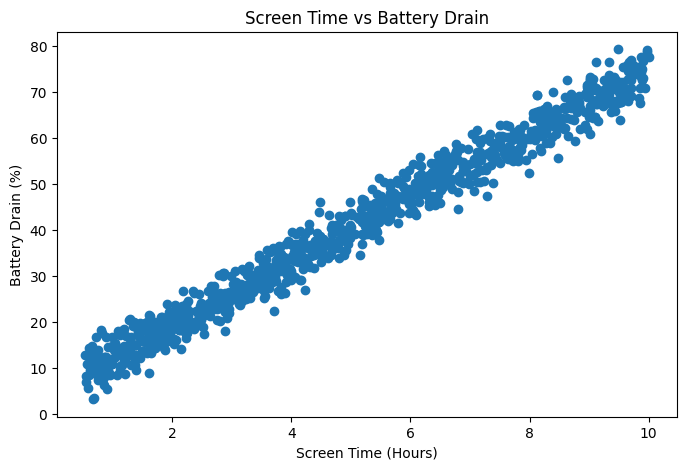

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Screen_Time_Hours"],
    df["Battery_Drain_Percent"]
)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Battery Drain (%)")
plt.title("Screen Time vs Battery Drain")

plt.show()

In [25]:
X = df[["Screen_Time_Hours"]]

y = df["Battery_Drain_Percent"]

print("Feature:", X.columns.tolist())
print("Target:", y.name)

Feature: ['Screen_Time_Hours']
Target: Battery_Drain_Percent


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 800
Testing Records: 200


In [27]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Simple Linear Regression Model Trained Successfully!")

Simple Linear Regression Model Trained Successfully!


In [28]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[34.20834743 62.95873867 39.62508781 32.54165808 71.77830314 73.02832015
 39.55564242 66.22267198 13.37473058 43.30569345]


In [29]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 2.161641009619794
Root Mean Squared Error (RMSE): 2.7780570640726467
R2 Score: 0.9793497970691634


In [30]:
result = pd.DataFrame({
    "Screen Time (Hours)": X_test["Screen_Time_Hours"].values,
    "Actual Battery Drain (%)": y_test.values,
    "Predicted Battery Drain (%)": np.round(y_pred, 2)
})

result.head(20)

,Screen Time (Hours),Actual Battery Drain (%),Predicted Battery Drain (%)
0,4.12,36.82,34.21
1,8.26,64.71,62.96
2,4.90,42.96,39.63
3,3.88,34.15,32.54
4,9.53,67.71,71.78
5,9.71,76.84,73.03
6,4.89,34.96,39.56
7,8.73,68.63,66.22
8,1.12,9.64,13.37
9,5.43,44.83,43.31


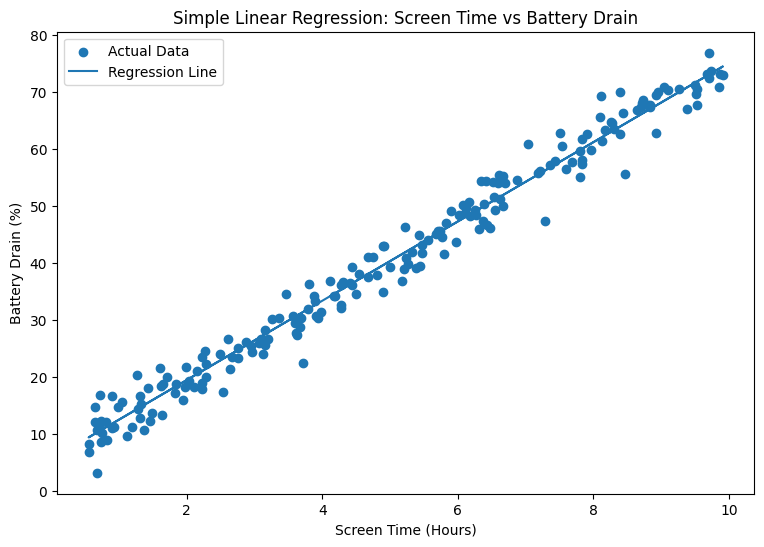

In [31]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_test,
    y_test,
    label="Actual Data"
)

plt.plot(
    X_test,
    y_pred,
    label="Regression Line"
)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Battery Drain (%)")
plt.title("Simple Linear Regression: Screen Time vs Battery Drain")

plt.legend()
plt.show()

In [32]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope (m):", slope)
print("Intercept (c):", intercept)

print("\nRegression Equation:")
print(f"Battery Drain = {slope:.2f} × Screen Time + {intercept:.2f}")

Slope (m): 6.94453894862435
Intercept (c): 5.5968469568308095

Regression Equation:
Battery Drain = 6.94 × Screen Time + 5.60


In [33]:
screen_hours = 6

new_data = pd.DataFrame({
    "Screen_Time_Hours": [screen_hours]
})

prediction = model.predict(new_data)

print(f"Screen Time: {screen_hours} hours")
print(f"Predicted Battery Drain: {prediction[0]:.2f}%")

Screen Time: 6 hours
Predicted Battery Drain: 47.26%


In [34]:
screen_hours = float(input("Enter Screen Time in hours: "))

new_data = pd.DataFrame({
    "Screen_Time_Hours": [screen_hours]
})

prediction = model.predict(new_data)

print("\n📱 Mobile Battery Prediction")
print("----------------------------")
print(f"Screen Time: {screen_hours} hours")
print(f"Predicted Battery Drain: {prediction[0]:.2f}%")

Enter Screen Time in hours: 5

📱 Mobile Battery Prediction
----------------------------
Screen Time: 5.0 hours
Predicted Battery Drain: 40.32%


In [35]:
import joblib

joblib.dump(model, "mobile_battery_drain_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
df.to_csv("mobile_battery_drain.csv", index=False)

In [37]:
from google.colab import files

files.download("mobile_battery_drain.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>